Original total variance: 7.1149
Variance after projection: 3.7841


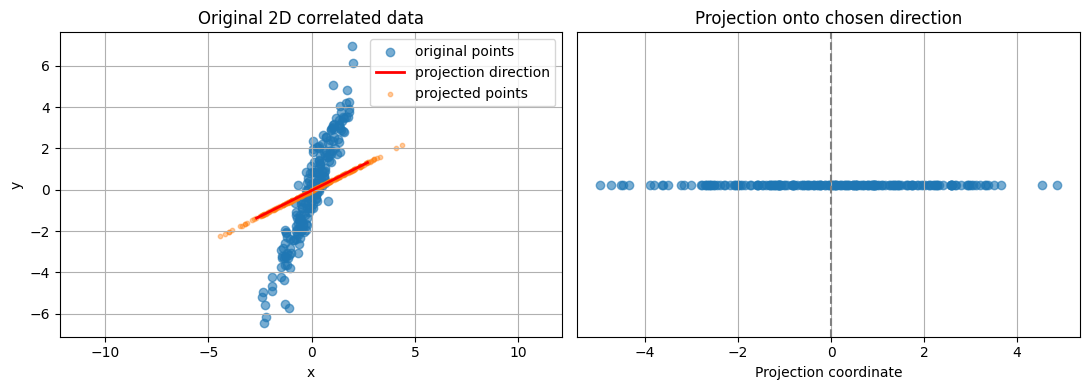

Read CSV file: manufacturing_6G_dataset.csv
             Timestamp  Machine_ID Operation_Mode  Temperature_C  \
0  2024-01-01 00:00:00          39           Idle      74.137590   
1  2024-01-01 00:01:00          29         Active      84.264558   
2  2024-01-01 00:02:00          15         Active      44.280102   
3  2024-01-01 00:03:00          43         Active      40.568502   
4  2024-01-01 00:04:00           8           Idle      75.063817   

   Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  Packet_Loss_%  \
0      3.500595              8.612162           10.650542       0.207764   
1      3.355928              2.268559           29.111810       2.228464   
2      2.079766              6.144105           18.357292       1.639416   
3      0.298238              4.067825           29.153629       1.161021   
4      0.345810              6.225737           34.029191       4.796520   

   Quality_Control_Defect_Rate_%  Production_Speed_units_per_hr  \
0                      

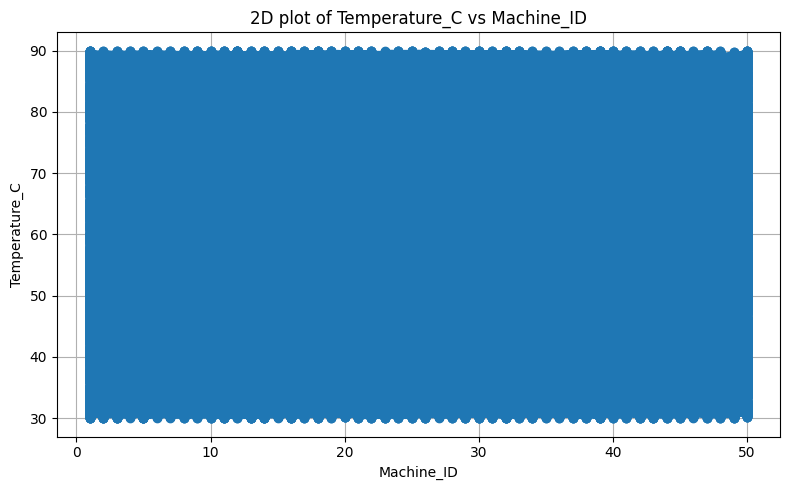

In [ ]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = rng.normal(0, 1, 200)
y = 2.5 * x + 0.8 * rng.normal(0, 1, 200)
data_2d = np.column_stack((x, y))

mean_2d = data_2d.mean(axis=0)
centered = data_2d - mean_2d

direction = np.array([2.0, 1.0])
direction = direction / np.linalg.norm(direction)

proj_scores = centered.dot(direction)
proj_points = np.outer(proj_scores, direction) + mean_2d

var_original = np.var(centered, axis=0, ddof=0).sum()
var_projection = np.var(proj_scores, ddof=0)

print(f"Original total variance: {var_original:.4f}")
print(f"Variance after projection: {var_projection:.4f}")

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.scatter(x, y, alpha=0.6, label='original points')
plt.plot(
    [mean_2d[0] - direction[0] * 3, mean_2d[0] + direction[0] * 3],
    [mean_2d[1] - direction[1] * 3, mean_2d[1] + direction[1] * 3],
    color='red',
    lw=2,
    label='projection direction'
)
plt.scatter(proj_points[:, 0], proj_points[:, 1], alpha=0.4, s=10, label='projected points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original 2D correlated data')
plt.axis('equal')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(proj_scores, np.zeros_like(proj_scores), alpha=0.6)
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Projection coordinate')
plt.yticks([])
plt.title('Projection onto chosen direction')
plt.grid(True)

plt.tight_layout()
plt.show()
csv_files = [f for f in os.listdir('.') if f.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the current folder.")

csv_path = csv_files[0]
df = pd.read_csv(csv_path)
print(f"Read CSV file: {csv_path}")
print(df.head())

numeric_cols = df.select_dtypes(include='number').columns
if len(numeric_cols) < 2:
    raise ValueError("Need at least two numeric columns to plot.")

x_col = numeric_cols[0]
y_col = numeric_cols[1]

plt.figure(figsize=(8, 5))
plt.plot(df[x_col], df[y_col], marker='o', linestyle='-')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"2D plot of {y_col} vs {x_col}")
plt.grid(True)
plt.tight_layout()
plt.show()